In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from hydra import compose, initialize

from severson_features_soh_rul.utils.plots import (
    create_figure
)

plt.style.use('../../.matplotlibrc')

In [2]:
with initialize(version_base=None, config_path='../../config'):
    cfg = compose(config_name="config")

In [3]:
ROOT_PATH = Path().absolute().parent.parent

In [4]:
features_path = ROOT_PATH / cfg['data']['features_data_path']

In [5]:
features_df = pd.read_parquet(features_path)
features_df.head()

,cell,cycle,SOH,charge_policy,throughput_ah_cycle,V_mean,V_median,V_std,V_iqr,V_kurtosis,...,charge_I_iqr,charge_I_kurtosis,charge_T_mean,charge_T_median,charge_T_std,charge_T_iqr,charge_T_kurtosis,RUL,throughput_ah_cumulative,RUL_THROUGHPUT
0,b1c16,1,98.287855,5.4C(60%)-3.6C,1.962667,3.113074,3.364936,0.525309,0.591460,-0.184578,...,5.119626,-1.594107,31.921679,31.924490,1.525122,2.170259,-0.781212,859,1.962667,1637.357551
1,b1c16,2,98.398618,5.4C(60%)-3.6C,1.964915,3.114386,3.364437,0.523411,0.591736,-0.176401,...,5.096980,-1.570353,31.944442,31.971531,1.503099,2.229275,-0.820880,858,3.927582,1635.392637
2,b1c16,3,98.487136,5.4C(60%)-3.6C,1.966634,3.112558,3.332523,0.518185,0.603142,-0.171407,...,5.145446,-1.527270,31.936617,31.965219,1.510386,2.145249,-0.831725,857,5.894215,1633.426003
3,b1c16,4,98.553618,5.4C(60%)-3.6C,1.967932,3.113084,3.336795,0.516932,0.604378,-0.166349,...,5.071867,-1.580688,31.965595,31.931253,1.527041,2.281160,-0.847546,856,7.862147,1631.458072
4,b1c16,5,98.604936,5.4C(60%)-3.6C,1.968876,3.116186,3.357531,0.517422,0.578248,-0.137306,...,5.118568,-1.536637,31.904419,31.945330,1.505957,2.189388,-0.772270,855,9.831023,1629.489195


In [6]:
required_cols = {"cell", "cycle", "RUL", "RUL_THROUGHPUT"}
missing_cols = required_cols - set(features_df.columns)
if missing_cols:
    raise ValueError(
        f"Missing required columns for comparison plot: {sorted(missing_cols)}"
    )

# Set to a specific cell id if desired, e.g. "b2c32".
example_cell = "b1c23"

available_cells = sorted(features_df["cell"].astype(str).unique().tolist())
if not available_cells:
    raise ValueError("No cells found in features dataset.")

if example_cell is None:
    example_cell = available_cells[0]

cell_df = (
    features_df[features_df["cell"].astype(str) == str(example_cell)]
    .sort_values("cycle")
    .copy()
)

if cell_df.empty:
    raise ValueError(f"Cell {example_cell} not found in features dataset.")

print(f"Example cell: {example_cell}")
print(f"Number of cycles: {cell_df.shape[0]}")
cell_df[["cell", "cycle", "RUL", "RUL_THROUGHPUT"]].head()

Example cell: b1c23
Number of cycles: 1012


,cell,cycle,RUL,RUL_THROUGHPUT
30108,b1c23,1,1011,1914.230286
30109,b1c23,2,1010,1912.267930
30110,b1c23,3,1009,1910.304368
30111,b1c23,4,1008,1908.339944
30112,b1c23,5,1007,1906.375252


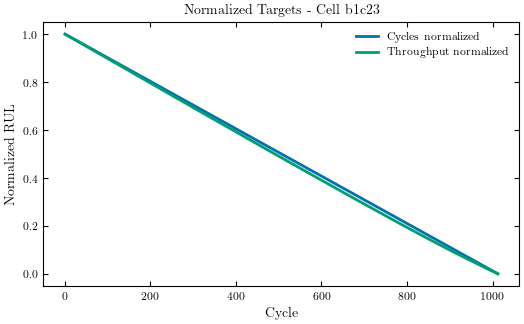

In [7]:
fig, ax = create_figure(layout_type="one_and_a_half")

# Normalized comparison (shape only).
rul_norm = cell_df["RUL"] / cell_df["RUL"].max()
rul_through_norm = cell_df["RUL_THROUGHPUT"] / cell_df["RUL_THROUGHPUT"].max()

ax.plot(
    cell_df["cycle"],
    rul_norm,
    label="Cycles normalized",
    linewidth=2,
    c="C0",
)
ax.plot(
    cell_df["cycle"],
    rul_through_norm,
    label="Throughput normalized",
    linewidth=2,
    c="C1",
)
ax.set_title(f"Normalized Targets - Cell {example_cell}")
ax.set_xlabel("Cycle")
ax.set_ylabel("Normalized RUL")
ax.legend()

plt.show()